In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
main_df = pd.read_csv('../data/inputs/application_train.csv')
prev_app_df = pd.read_csv('../data/inputs/previous_application.csv')

main_df.shape, prev_app_df.shape

((307511, 122), (1670214, 37))

In [3]:
prev_app_df.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
prev_app_df = prev_app_df.sort_values(['SK_ID_CURR', 'DAYS_DECISION'], ascending=[True, False]) \
                         .drop_duplicates('SK_ID_CURR', keep='first')

prev_app_df.shape

(338857, 37)

In [5]:
merged_df = main_df.merge(
    prev_app_df,
    how='left',
    on='SK_ID_CURR'
)
merged_df.shape

(307511, 158)

In [6]:
import pandas as pd

merged_df['MONTH_LABEL'] = np.ceil(merged_df['DAYS_DECISION'] / 30)
merged_df['MONTH_LABEL'] = merged_df['MONTH_LABEL'].astype('Int64')
merged_df['MONTH_LABEL'] = merged_df['MONTH_LABEL'].astype(str)

print(merged_df[['DAYS_DECISION', 'MONTH_LABEL']])

        DAYS_DECISION MONTH_LABEL
0              -606.0         -20
1              -746.0         -24
2              -815.0         -27
3              -181.0          -6
4              -374.0         -12
...               ...         ...
307506         -273.0          -9
307507        -2497.0         -83
307508        -1909.0         -63
307509         -277.0          -9
307510         -171.0          -5

[307511 rows x 2 columns]


C:\Users\DILSHOD\AppData\Local\Temp\ipykernel_28732\1631283933.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df['MONTH_LABEL'] = np.ceil(merged_df['DAYS_DECISION'] / 30)


### 90 DAYS

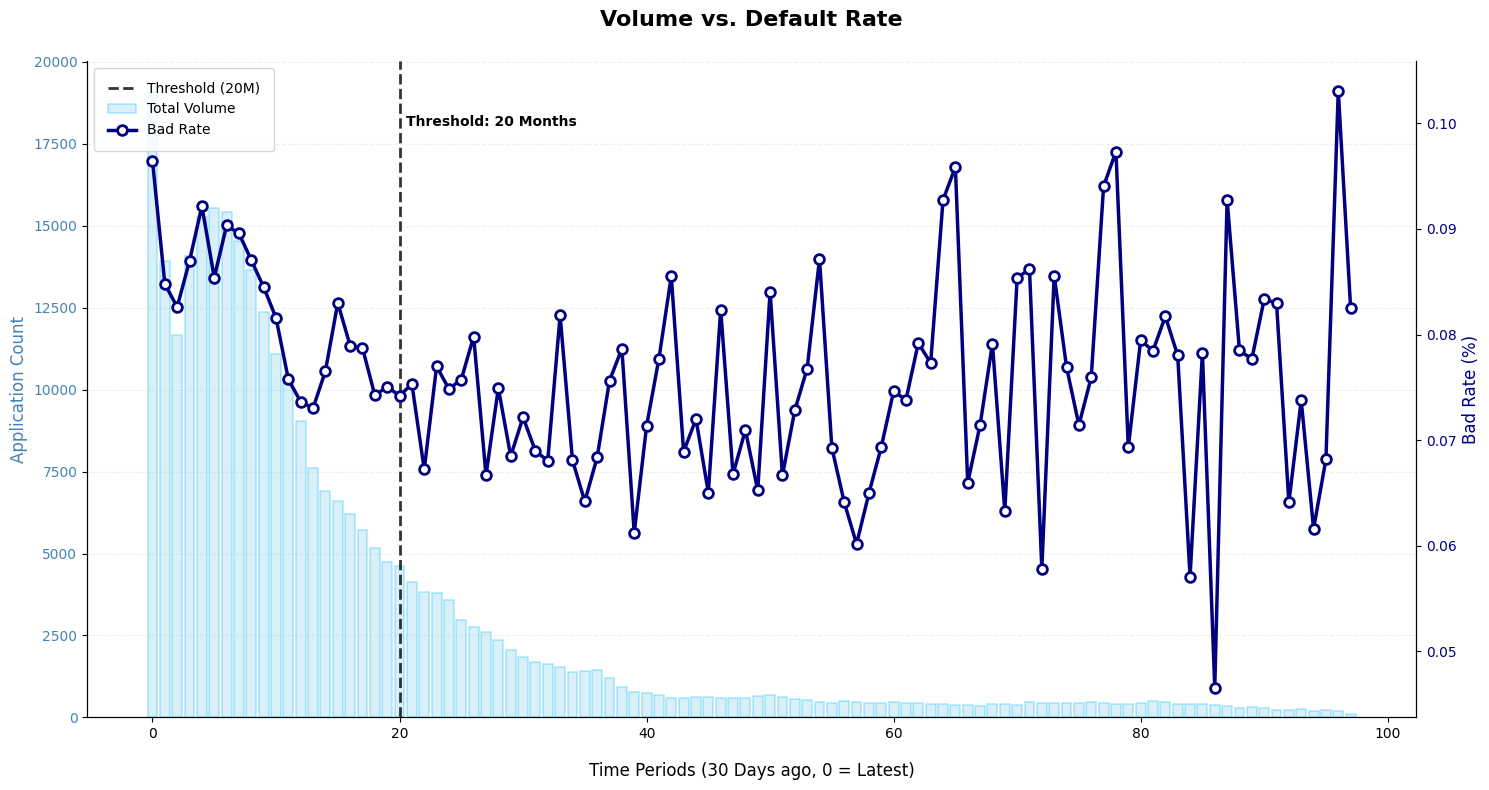

In [8]:
DAYS_TO_DEVIDE = 30
THRESHOLD_MONTH = 20

merged_df['MONTH_LABEL'] = (np.abs(merged_df['DAYS_DECISION']) // DAYS_TO_DEVIDE).astype('Int64')
stats = merged_df.groupby('MONTH_LABEL')['TARGET'].agg(['mean', 'count']).sort_index()

fig, ax1 = plt.subplots(figsize=(15, 8))

ax1.bar(stats.index, stats['count'], color='skyblue', alpha=0.3, label='Total Volume', edgecolor='deepskyblue', linewidth=1.2)
ax1.set_xlabel(f'Time Periods ({DAYS_TO_DEVIDE} Days ago, 0 = Latest)', fontsize=12, labelpad=15)
ax1.set_ylabel('Application Count', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(axis='y', linestyle='--', alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(stats.index, stats['mean'], color='navy', marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2, linewidth=2.5, label='Bad Rate')
ax2.set_ylabel('Bad Rate (%)', color='navy', fontsize=12)
ax2.tick_params(axis='y', labelcolor='navy')

# ADD VERTICAL THRESHOLD LINE
ax1.axvline(x=THRESHOLD_MONTH, color='black', linestyle='--', linewidth=2, alpha=0.8, label=f'Threshold ({THRESHOLD_MONTH}M)')
ax1.text(THRESHOLD_MONTH + 0.5, ax1.get_ylim()[1] * 0.9, f'Threshold: {THRESHOLD_MONTH} Months', 
         color='black', fontweight='bold', fontsize=10)

plt.title('Volume vs. Default Rate', fontsize=16, pad=25, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, borderpad=1)

fig.tight_layout()
plt.show()

### CHANGE of ROC-AUC over time 

In [12]:
plot_data = pd.read_csv('../outputs/lr_mrmr_2026-04-06_15-59-25/results/evaluation_metrics_summary.csv')
needed_data_for_plot = plot_data[['fold', 'auc', 'psi_model']]

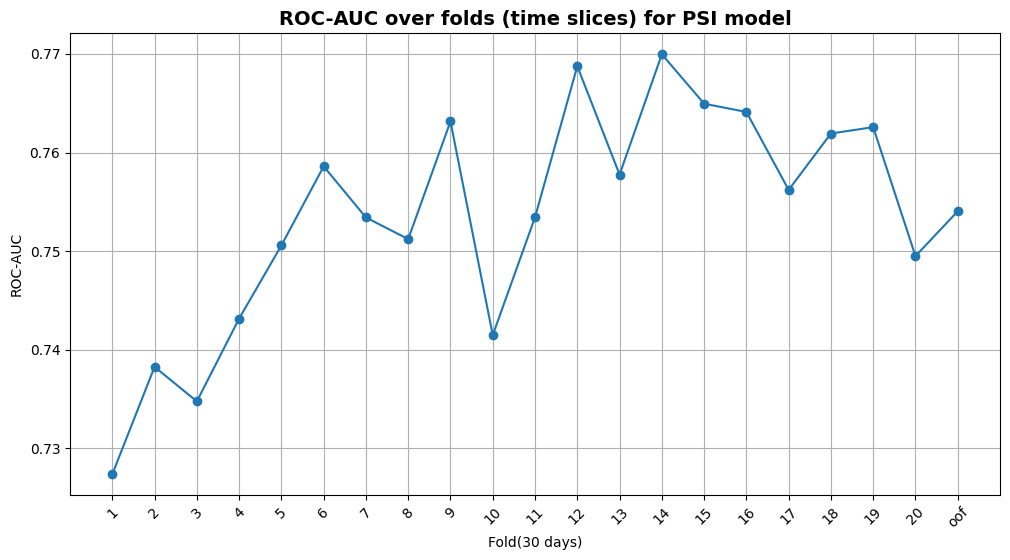

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(needed_data_for_plot["fold"], needed_data_for_plot["auc"], marker='o', linestyle='-')
plt.title("ROC-AUC over folds (time slices) for PSI model", fontsize=14, fontweight='bold')
plt.xlabel("Fold(30 days)")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45)
plt.grid(True)

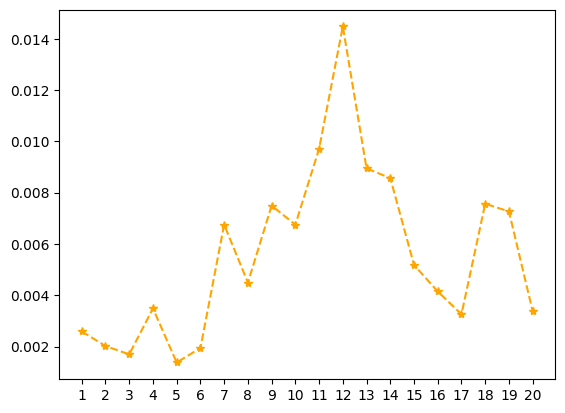

In [16]:

plt.plot(needed_data_for_plot["fold"], needed_data_for_plot["psi_model"], marker='*', color='orange', linestyle='--')

In [11]:
import warnings
import os

warnings.filterwarnings("ignore")

path = "../data/inputs/"
files = [f for f in os.listdir(path) if f.endswith('.csv')]

for file in files:
    var_name = file.replace('.csv', '').lower() + "_df"
    globals()[var_name] = pd.read_csv(os.path.join(path, file))
    print(f"Variable '{var_name}' is ready with the shape {globals()[var_name].shape}.")


Variable 'application_train_df' is ready with the shape (307511, 122).
Variable 'bureau_df' is ready with the shape (1716428, 17).
Variable 'bureau_balance_df' is ready with the shape (27299925, 3).
Variable 'credit_card_balance_df' is ready with the shape (3840312, 23).
Variable 'installments_payments_df' is ready with the shape (13605401, 8).
Variable 'pos_cash_balance_df' is ready with the shape (10001358, 8).
Variable 'previous_application_df' is ready with the shape (1670214, 37).
